In [1]:
import cv2
import os
import pandas as pd

os.makedirs("../data/preprocessed/sehat", exist_ok=True)
os.makedirs("../data/preprocessed/terkontaminasi", exist_ok=True)

TARGET_SIZE = (128, 128)

# Muat ulang manifest hasil Fase 2, supaya tidak perlu deteksi ulang dari awal
df_manifest = pd.read_csv("../data/manifest_crop.csv")

for idx, row in df_manifest.iterrows():
    folder_asal = f"../data/cropped/{row['label']}"
    folder_tujuan = f"../data/preprocessed/{row['label']}"
    img_path = os.path.join(folder_asal, row['filename'])
    img = cv2.imread(img_path)

    # Resize ke ukuran seragam. INTER_CUBIC dipilih karena kita MEMPERBESAR gambar kecil
    # (interpolasi kubik menghasilkan transisi piksel lebih halus dibanding metode default)
    img_resized = cv2.resize(img, TARGET_SIZE, interpolation=cv2.INTER_CUBIC)

    # Gaussian blur ringan untuk meredam noise/artefak yang muncul akibat proses upscaling
    img_final = cv2.GaussianBlur(img_resized, (3, 3), 0)

    path_simpan = os.path.join(folder_tujuan, row["filename"])
    cv2.imwrite(path_simpan, img_final)

print(f"Preprocessing selesai untuk {len(df_manifest)} crop.")

Preprocessing selesai untuk 235 crop.


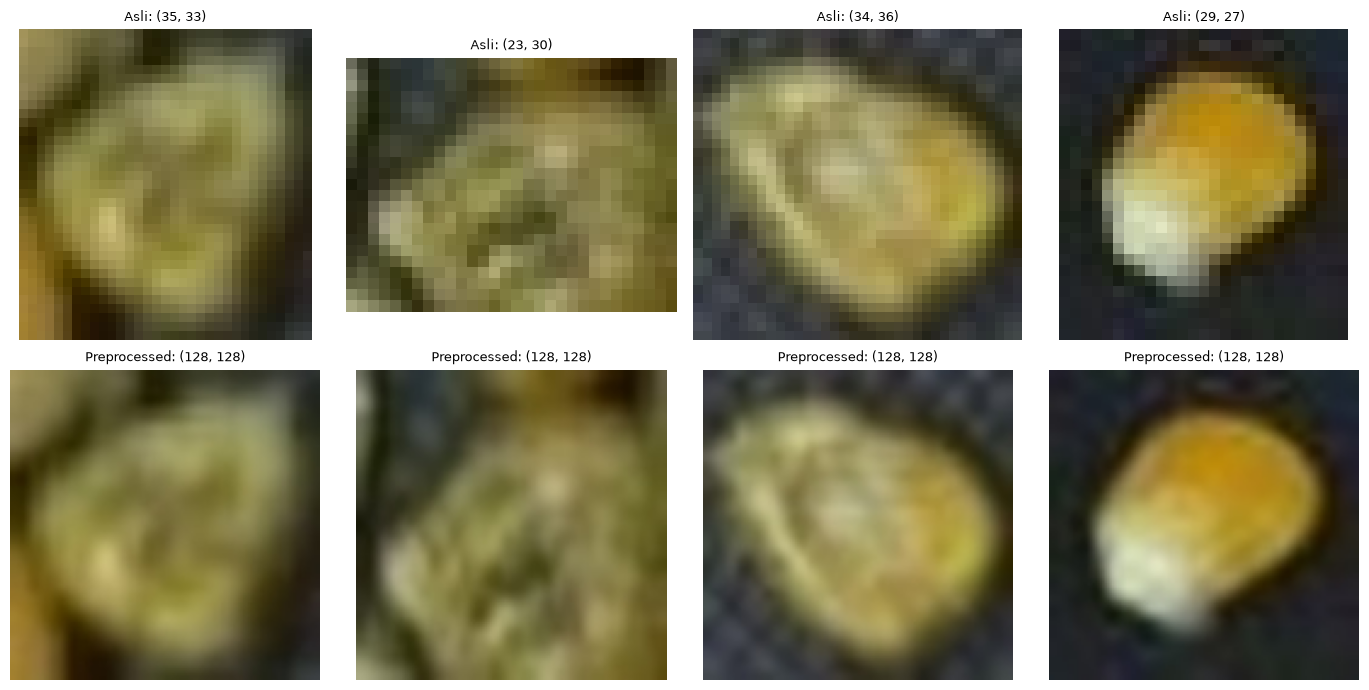

In [2]:
import matplotlib.pyplot as plt

# Ambil 4 sampel acak untuk dibandingkan crop asli vs hasil preprocessing
sampel = df_manifest.sample(n=4, random_state=1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))

for i, (_, row) in enumerate(sampel.iterrows()):
    path_asli = f"../data/cropped/{row['label']}/{row['filename']}"
    path_baru = f"../data/preprocessed/{row['label']}/{row['filename']}"

    img_asli = cv2.cvtColor(cv2.imread(path_asli), cv2.COLOR_BGR2RGB)
    img_baru = cv2.cvtColor(cv2.imread(path_baru), cv2.COLOR_BGR2RGB)

    axes[0, i].imshow(img_asli)
    axes[0, i].set_title(f"Asli: {img_asli.shape[:2]}", fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(img_baru)
    axes[1, i].set_title(f"Preprocessed: {img_baru.shape[:2]}", fontsize=9)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()